---
# Batch Stage Tracker

**Use case:** Before PharmaOps can make any decision about a batch, it needs
a record of what's happened to that batch so far. This is the simplest
possible LangGraph — no LLM, no decisions — but it establishes the state
shape (`batch_id`, `stage_log`) that every later example reads from or
writes to. This is the plumbing lesson: state flows through nodes, edges
carry control not data.

In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [5]:
# Define state

class BatchTrackingState(TypedDict):

    batch_id: str
    stage_log: str  # human-readable trail of what's happened to this batch

### Implement 3 nodes

- **log_material_receipt**
  - takes initial state as input and returns an updated dictionary((Will return only one element as a dictionary)))
- **log_formulation_complete**
  - takes state as input and returns an updated dictionary
- **log_qc_check**
  - takes state as input and returns an updated dictionary

In [6]:
def log_material_receipt(state: BatchTrackingState) -> dict:

    """Record that raw materials for this batch have arrived and been logged."""
    updated_log = state["stage_log"] + " -> Raw materials received"

    print(f"[MATERIAL RECEIPT] {updated_log}")
    return {"stage_log": updated_log}

def log_formulation_complete(state: BatchTrackingState) -> dict:

    """Record that the batch has been formulated per the master batch record."""
    updated_log = state["stage_log"] + " -> Formulation complete"

    print(f"[FORMULATION] {updated_log}")
    return {"stage_log": updated_log}

def log_qc_check(state: BatchTrackingState) -> dict:

    """Record that the batch has passed through the quality control checkpoint."""
    updated_log = state["stage_log"] + " -> QC checkpoint passed"
    
    print(f"[QUALITY CONTROL] {updated_log}")
    return {"stage_log": updated_log}

In [ ]:
batch_graph = StateGraph(BatchTrackingState)

# Define nodes
batch_graph.add_node("log_material_receipt", log_material_receipt)
batch_graph.add_node("log_formulation_complete", log_formulation_complete)
batch_graph.add_node("log_qc_check", log_qc_check)

# Define connections between nodes(called as edge in Langgraph))
batch_graph.add_edge(START, "log_material_receipt")
batch_graph.add_edge("log_material_receipt", "log_formulation_complete")
batch_graph.add_edge("log_formulation_complete", "log_qc_check")
batch_graph.add_edge("log_qc_check", END)

batch_tracker_app = batch_graph.compile()

In [9]:
initial_batch_state = {"batch_id": "PC-2026-0091", "stage_log": "Batch opened"}
final_batch_state = batch_tracker_app.invoke(initial_batch_state)

print()
print(final_batch_state)


[MATERIAL RECEIPT] Batch opened -> Raw materials received
[FORMULATION] Batch opened -> Raw materials received -> Formulation complete
[QUALITY CONTROL] Batch opened -> Raw materials received -> Formulation complete -> QC checkpoint passed

{'batch_id': 'PC-2026-0091', 'stage_log': 'Batch opened -> Raw materials received -> Formulation complete -> QC checkpoint passed'}


### Display the graph

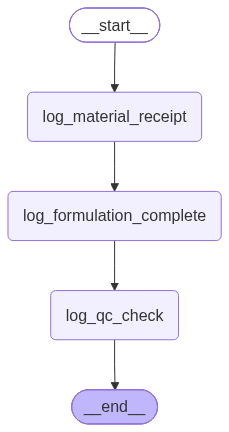

In [8]:
batch_tracker_app